<a href="https://colab.research.google.com/github/cu24250113-priyashi/Computer_Vision/blob/main/Labsheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LAB SHEET - 4

####PRIYASHI
####B-TECH CSE
####ROLL NO 39

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift

In [ ]:
image_path = "/content/tiger.jpeg"
img = cv2.imread(image_path, -1)


1. Built a tool that computes and visualized 2D Fourier spectrum(magnitude and phase) of an image.


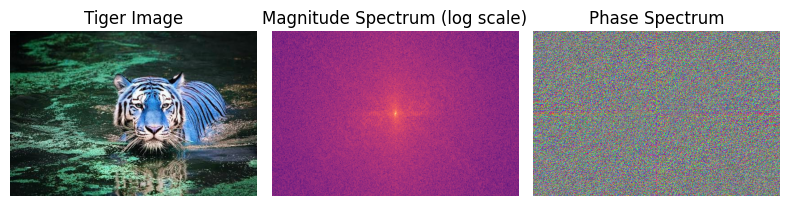

In [ ]:
def plot_fourier_spectrum(image, title="Original Image"):
    if len(image.shape) == 3:
        image_for_fft = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        display_image_original = image
        cmap_original = None
    else:
        image_for_fft = image
        display_image_original = image
        cmap_original = 'gray'
    F = fft2(image_for_fft)
    F_shifted = fftshift(F)
    magnitude_spectrum = np.log(np.abs(F_shifted) + 1)
    phase_spectrum = np.angle(F_shifted)
    fig, axes = plt.subplots(1, 3, figsize=(8, 5))
    axes[0].imshow(display_image_original, cmap=cmap_original)
    axes[0].set_title(title)
    axes[0].axis('off')
    axes[1].imshow(magnitude_spectrum, cmap='magma')
    axes[1].set_title('Magnitude Spectrum (log scale)')
    axes[1].axis('off')
    axes[2].imshow(phase_spectrum, cmap='hsv')
    axes[2].set_title('Phase Spectrum')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()
plot_fourier_spectrum(img, title="Tiger Image")
#Priyashi(39)

2.
Develop a frequency-Domain Low-Pass Filters(Ideal, Butterworth, and Gaussian) and compare the resulting blur effects.

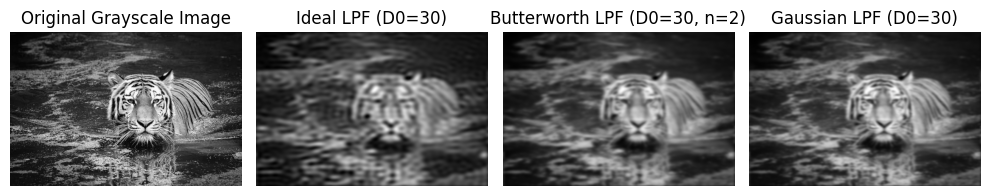

In [ ]:
if len(img.shape) == 3:
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
else:
    gray_img = img
M, N = gray_img.shape
F_gray = fft2(gray_img)
F_shifted_gray = fftshift(F_gray)
u = np.arange(M)
v = np.arange(N)
U, V = np.meshgrid(u, v, indexing='ij')
D_uv = np.sqrt((U - M/2)**2 + (V - N/2)**2)
D0 = 30
n = 2
H_ilpf = np.zeros((M, N), dtype=np.float32)
H_ilpf[D_uv <= D0] = 1
G_ilpf_shifted = F_shifted_gray * H_ilpf
G_ilpf_unshifted = fftshift(G_ilpf_shifted)
img_ilpf_complex = np.fft.ifft2(G_ilpf_unshifted)
img_ilpf = np.abs(img_ilpf_complex)
img_ilpf_normalized = cv2.normalize(img_ilpf, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
H_blpf = 1 / (1 + (D_uv / D0)**(2 * n))
G_blpf_shifted = F_shifted_gray * H_blpf
G_blpf_unshifted = fftshift(G_blpf_shifted)
img_blpf_complex = np.fft.ifft2(G_blpf_unshifted)
img_blpf = np.abs(img_blpf_complex)
img_blpf_normalized = cv2.normalize(img_blpf, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
H_glpf = np.exp(-(D_uv**2) / (2 * D0**2))
G_glpf_shifted = F_shifted_gray * H_glpf
G_glpf_unshifted = fftshift(G_glpf_shifted)
img_glpf_complex = np.fft.ifft2(G_glpf_unshifted)
img_glpf = np.abs(img_glpf_complex)
img_glpf_normalized = cv2.normalize(img_glpf, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
fig, axes = plt.subplots(1, 4, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original Grayscale Image')
axes[0].axis('off')
axes[1].imshow(img_ilpf_normalized, cmap='gray')
axes[1].set_title(f'Ideal LPF (D0={D0})')
axes[1].axis('off')
axes[2].imshow(img_blpf_normalized, cmap='gray')
axes[2].set_title(f'Butterworth LPF (D0={D0}, n={n})')
axes[2].axis('off')
axes[3].imshow(img_glpf_normalized, cmap='gray')
axes[3].set_title(f'Gaussian LPF (D0={D0})')
axes[3].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)


3. Develop a frequency-domain hight-pass filter to enhance edges,and compare the result with spatial-domain edge detection.


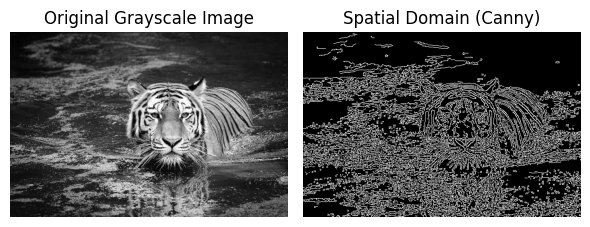

In [ ]:
D0 = 30
n = 2
H_ihpf = np.ones((M, N), dtype=np.float32)
H_ihpf[D_uv <= D0] = 0
G_ihpf_shifted = F_shifted_gray * H_ihpf
G_ihpf_unshifted = fftshift(G_ihpf_shifted)
img_ihpf_complex = np.fft.ifft2(G_ihpf_unshifted)
img_ihpf = np.abs(img_ihpf_complex)
img_ihpf_normalized = cv2.normalize(img_ihpf, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
H_bhpf = 1 - (1 / (1 + (D_uv / D0)**(2 * n)))
G_bhpf_shifted = F_shifted_gray * H_bhpf
G_bhpf_unshifted = fftshift(G_bhpf_shifted)
img_bhpf_complex = np.fft.ifft2(G_bhpf_unshifted)
img_bhpf = np.abs(img_bhpf_complex)
img_bhpf_normalized = cv2.normalize(img_bhpf, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
H_ghpf = 1 - np.exp(-(D_uv**2) / (2 * D0**2))
G_ghpf_shifted = F_shifted_gray * H_ghpf
G_ghpf_unshifted = fftshift(G_ghpf_shifted)
img_ghpf_complex = np.fft.ifft2(G_ghpf_unshifted)
img_ghpf = np.abs(img_ghpf_complex)
img_ghpf_normalized = cv2.normalize(img_ghpf, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
canny_edges = cv2.Canny(gray_img, threshold1=100, threshold2=200)
fig, axes = plt.subplots(1, 2, figsize=(6, 6))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original Grayscale Image')
axes[0].axis('off')
axes[1].imshow(canny_edges, cmap='gray')
axes[1].set_title('Spatial Domain (Canny)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)

4. Build a periodic-noise removal tool that identifies and removes noise spikes visible in the frequency spectrum

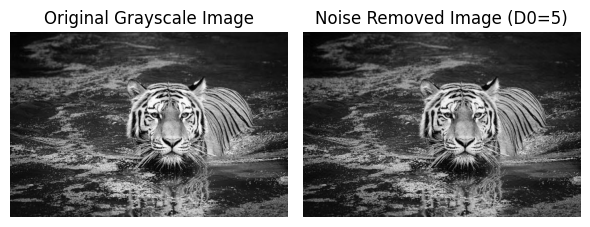

In [ ]:
def create_ideal_notch_reject_filter(shape, notch_points, D0):
    H = np.ones(shape, dtype=np.float32)
    M, N = shape
    u = np.arange(M)
    v = np.arange(N)
    U, V = np.meshgrid(u, v, indexing='ij')
    for (u_k, v_k) in notch_points:
        D_k = np.sqrt((U - u_k)**2 + (V - v_k)**2)
        H[D_k <= D0] = 0
        u_k_conj = M - 1 - u_k if u_k != 0 else 0
        v_k_conj = N - 1 - v_k if v_k != 0 else 0
        D_k_conj = np.sqrt((U - u_k_conj)**2 + (V - v_k_conj)**2)
        H[D_k_conj <= D0] = 0
    return H
center_u, center_v = M // 2, N // 2
notch_locations = []
notch_locations.append((center_u - 50, center_v - 50))
notch_locations.append((center_u + 50, center_v + 50))
notch_locations.append((center_u - 50, center_v + 50))
notch_locations.append((center_u + 50, center_v - 50))
noise_D0 = 5
if not notch_locations:
    print("No noise locations provided. The notch filter will not be applied.")
    H_notch = np.ones((M, N), dtype=np.float32)
else:
    H_notch = create_ideal_notch_reject_filter((M, N), notch_locations, noise_D0)
G_notch_shifted = F_shifted_gray * H_notch
G_notch_unshifted = fftshift(G_notch_shifted)
img_notch_complex = np.fft.ifft2(G_notch_unshifted)
img_notch = np.abs(img_notch_complex)
img_notch_normalized = cv2.normalize(img_notch, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
fig, axes = plt.subplots(1, 2, figsize=(6, 6))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original Grayscale Image')
axes[0].axis('off')
axes[1].imshow(img_notch_normalized, cmap='gray')
axes[1].set_title(f'Noise Removed Image (D0={noise_D0})')
axes[1].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)


5. Develop a program that compresses an image by retaining only the top-k Fourier coefficient and reconstructs it.

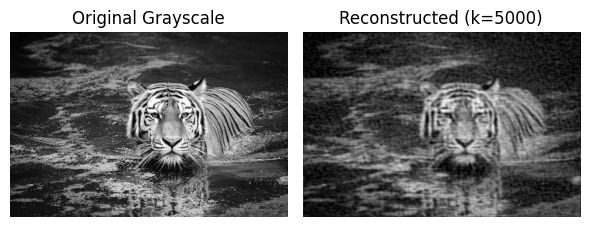

In [ ]:
def compress_image_fourier(image, k):
    if len(image.shape) == 3:
        gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray_img = image
    F = fft2(gray_img)
    F_shifted = fftshift(F)
    flat_F_shifted = F_shifted.flatten()
    top_k_indices = np.argsort(np.abs(flat_F_shifted))[::-1][:k]
    compressed_F_shifted = np.zeros_like(F_shifted)
    rows, cols = F_shifted.shape
    for idx in top_k_indices:
        r = idx // cols
        c = idx % cols
        compressed_F_shifted[r, c] = F_shifted[r, c]
    compressed_F = fftshift(compressed_F_shifted)
    reconstructed_img = np.abs(ifft2(compressed_F))
    reconstructed_img_normalized = cv2.normalize(reconstructed_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return gray_img, reconstructed_img_normalized, np.log(np.abs(F_shifted) + 1), np.log(np.abs(compressed_F_shifted) + 1)
k_values = [5000]
plt.figure(figsize=(6, 5))
for i, k in enumerate(k_values):
    original_gray, reconstructed_img, original_spectrum, compressed_spectrum = compress_image_fourier(img, k)
    plt.subplot(1, 2, 1)
    plt.imshow(original_gray, cmap='gray')
    plt.title('Original Grayscale')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_img, cmap='gray')
    plt.title(f'Reconstructed (k={k})')
    plt.axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)

6. Create a watermark hide/reveal tool that embeds and extracts a watermark using frequency-domain manipulation.

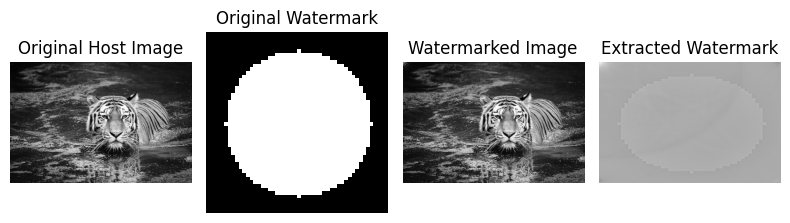

Watermark embedded and extracted successfully!


In [ ]:
def embed_watermark(host_image_data, watermark_image_data, alpha=20):
    image_float = np.float32(host_image_data)
    if watermark_image_data.shape != host_image_data.shape:
        watermark_resized = cv2.resize(
            watermark_image_data,
            (host_image_data.shape[1], host_image_data.shape[0]),
            interpolation=cv2.INTER_AREA
        )
    else:
        watermark_resized = watermark_image_data
    _, watermark_binary = cv2.threshold(
        watermark_resized,
        127,
        255,
        cv2.THRESH_BINARY
    )
    watermark_float = np.float32(watermark_binary) / 255.
    dct_image = cv2.dct(image_float)
    watermarked_dct = dct_image + alpha * watermark_float
    watermarked_image = cv2.idct(watermarked_dct)
    watermarked_image = np.clip(
        watermarked_image,
        0,
        255
    ).astype(np.uint8)
    return watermarked_image
def extract_watermark(
    original_image_data,
    watermarked_image_data,
    alpha=20
):
    original = np.float32(original_image_data)
    watermarked = np.float32(watermarked_image_data)
    original_dct = cv2.dct(original)
    watermarked_dct = cv2.dct(watermarked)
    difference = watermarked_dct - original_dct
    extracted = difference / alpha
    extracted = cv2.normalize(
        extracted,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )
    extracted = extracted.astype(np.uint8)
    return extracted
watermark_size = 50
watermark_data = np.zeros(
    (watermark_size, watermark_size),
    dtype=np.uint8
)
cv2.circle(
    watermark_data,
    (watermark_size // 2, watermark_size // 2),
    20,
    255,
    -1
)
host_image_data = (
    cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if len(img.shape) == 3
    else img
)
alpha_value = 20
watermarked_img_result = embed_watermark(
    host_image_data,
    watermark_data,
    alpha=alpha_value
)
extracted_watermark_result = extract_watermark(
    host_image_data,
    watermarked_img_result,
    alpha=alpha_value
)
plt.figure(figsize=(8, 4))
plt.subplot(1, 4, 1)
plt.imshow(host_image_data, cmap="gray")
plt.title("Original Host Image")
plt.axis("off")
plt.subplot(1, 4, 2)
plt.imshow(watermark_data, cmap="gray")
plt.title("Original Watermark")
plt.axis("off")
plt.subplot(1, 4, 3)
plt.imshow(watermarked_img_result, cmap="gray")
plt.title("Watermarked Image")
plt.axis("off")
plt.subplot(1, 4, 4)
plt.imshow(extracted_watermark_result, cmap="gray")
plt.title("Extracted Watermark")
plt.axis("off")
plt.tight_layout()
plt.show()
print("Watermark embedded and extracted successfully!")
#Priyashi(39)

7. Build a band-pass/band-reject filter designer for isolation specific frequency ranges in a textured image.

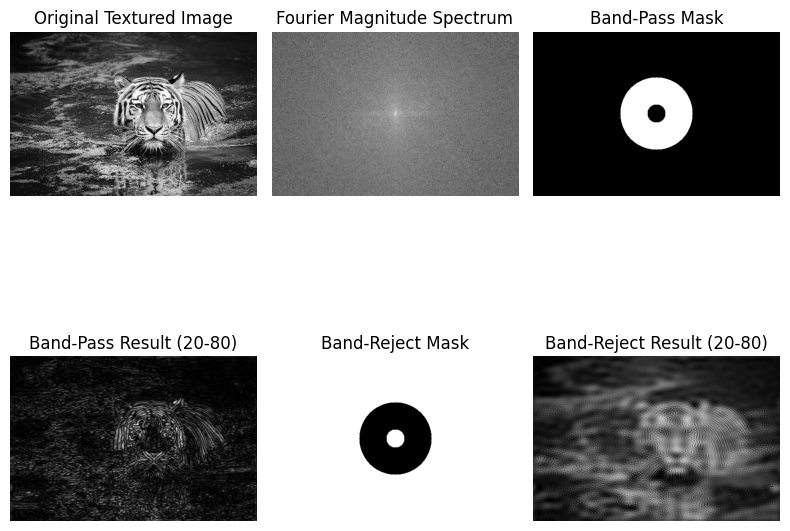

Filtering completed successfully.
Band-pass result saved as: bandpass_result.jpg
Band-reject result saved as: bandreject_result.jpg


In [ ]:
def band_filter(image, low_cutoff, high_cutoff, filter_type="bandpass"):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(
        np.abs(fshift) + 1
    )
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2
    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt(
        (x - ccol) ** 2 +
        (y - crow) ** 2
    )
    bandpass_mask = (
        (distance >= low_cutoff) &
        (distance <= high_cutoff)
    )
    bandpass_mask = bandpass_mask.astype(np.float32)
    if filter_type.lower() == "bandpass":
        mask = bandpass_mask
    elif filter_type.lower() == "bandreject":
        mask = 1 - bandpass_mask
    else:
        raise ValueError(
            "filter_type must be 'bandpass' or 'bandreject'"
        )
    filtered_frequency = fshift * mask
    f_ishift = np.fft.ifftshift(filtered_frequency)
    filtered_image = np.fft.ifft2(f_ishift)
    filtered_image = np.abs(filtered_image)
    filtered_image = cv2.normalize(
        filtered_image,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)
    return filtered_image, mask, magnitude_spectrum
image = cv2.imread("/content/tiger.jpeg", cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError(
        "Could not find textured_image.jpg"
    )
low_cutoff = 20
high_cutoff = 80
bandpass_result, bandpass_mask, spectrum = band_filter(
    image,
    low_cutoff,
    high_cutoff,
    "bandpass"
)
bandreject_result, bandreject_mask, _ = band_filter(
    image,
    low_cutoff,
    high_cutoff,
    "bandreject"
)
plt.figure(figsize=(8,8))
plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Textured Image")
plt.axis("off")
plt.subplot(2, 3, 2)
plt.imshow(spectrum, cmap="gray")
plt.title("Fourier Magnitude Spectrum")
plt.axis("off")
plt.subplot(2, 3, 3)
plt.imshow(bandpass_mask, cmap="gray")
plt.title("Band-Pass Mask")
plt.axis("off")
plt.subplot(2, 3, 4)
plt.imshow(bandpass_result, cmap="gray")
plt.title(
    f"Band-Pass Result ({low_cutoff}-{high_cutoff})"
)
plt.axis("off")
plt.subplot(2, 3, 5)
plt.imshow(bandreject_mask, cmap="gray")
plt.title("Band-Reject Mask")
plt.axis("off")
plt.subplot(2, 3, 6)
plt.imshow(bandreject_result, cmap="gray")
plt.title(
    f"Band-Reject Result ({low_cutoff}-{high_cutoff})"
)
plt.axis("off")
plt.tight_layout()
plt.show()
cv2.imwrite(
    "bandpass_result.jpg",
    bandpass_result
)
cv2.imwrite(
    "bandreject_result.jpg",
    bandreject_result
)
cv2.imwrite(
    "bandpass_mask.jpg",
    (bandpass_mask * 255).astype(np.uint8)
)
cv2.imwrite(
    "bandreject_mask.jpg",
    (bandreject_mask * 255).astype(np.uint8)
)
print("Filtering completed successfully.")
print("Band-pass result saved as: bandpass_result.jpg")
print("Band-reject result saved as: bandreject_result.jpg")
#Priyashi(39)


8. Develop a demo that swaps the phase and magnitude components between two images to show their relative importances.

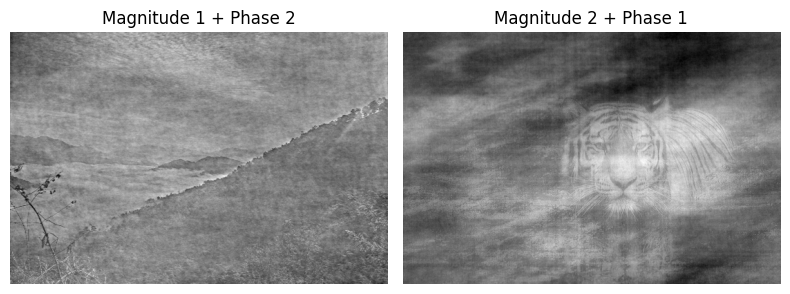

In [ ]:
img1 = cv2.imread("/content/tiger.jpeg", 0)
img2 = cv2.imread("/content/Picture.jpg.jpeg", 0)
if img1 is None:
    raise FileNotFoundError("tiger.jpeg.jpg not found")
if img2 is None:
    raise FileNotFoundError("Picture.jpg.jpeg not found")
img2 = cv2.resize(
    img2,
    (img1.shape[1], img1.shape[0])
)
f1 = np.fft.fft2(img1)
f2 = np.fft.fft2(img2)
mag1 = np.abs(f1)
mag2 = np.abs(f2)
phase1 = np.angle(f1)
phase2 = np.angle(f2)
swap1 = mag1 * np.exp(1j * phase2)
swap2 = mag2 * np.exp(1j * phase1)
result1 = np.real(np.fft.ifft2(swap1))
result2 = np.real(np.fft.ifft2(swap2))
result1 = cv2.normalize(
    result1, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)
result2 = cv2.normalize(
    result2, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(result1, cmap="gray")
plt.title("Magnitude 1 + Phase 2")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(result2, cmap="gray")
plt.title("Magnitude 2 + Phase 1")
plt.axis("off")
plt.tight_layout()
plt.show()
#Priyashi(39)


9. create a blur detection tool that flags blurry images based on the high frequency energy content of their spectrum.

In [ ]:
def detect_blur(image, threshold=1000):
    if len(image.shape) == 3:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray_image = image
    f = np.fft.fft2(gray_image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = np.abs(fshift)
    rows, cols = gray_image.shape
    crow, ccol = rows // 2, cols // 2
    inner_radius = min(crow, ccol) // 4
    outer_radius = min(crow, ccol) // 2
    y, x = np.ogrid[-crow:rows - crow, -ccol:cols - ccol]
    mask = (x*x + y*y >= inner_radius**2) & (x*x + y*y <= outer_radius**2)
    high_freq_energy = np.sum(magnitude_spectrum[mask])
    is_blurry = high_freq_energy < threshold
    return is_blurry, high_freq_energy, magnitude_spectrum
original_image_for_blur = img.copy()
blurred_image = cv2.GaussianBlur(original_image_for_blur, (25, 25), 0)
blur_threshold = 5000000
is_original_blurry, original_energy, original_mag_spectrum = detect_blur(
    original_image_for_blur,
    threshold=blur_threshold
)
is_blurred_blurry, blurred_energy, blurred_mag_spectrum = detect_blur(
    blurred_image,
    threshold=blur_threshold
)
print(f"Original Image - Blurry: {is_original_blurry}, High-Frequency Energy: {original_energy:.2e}")
print(f"Blurred Image - Blurry: {is_blurred_blurry}, High-Frequency Energy: {blurred_energy:.2e}")
print("Note: The blur_threshold might need adjustment based on the characteristics of your images.")
#Priyashi(39)

Original Image - Blurry: False, High-Frequency Energy: 4.60e+08
Blurred Image - Blurry: False, High-Frequency Energy: 2.20e+07
Note: The blur_threshold might need adjustment based on the characteristics of your images.


10. Build a side-by-side visualizer that applies the same type of filtering in both the spatial and frequency domains and displays the results together.

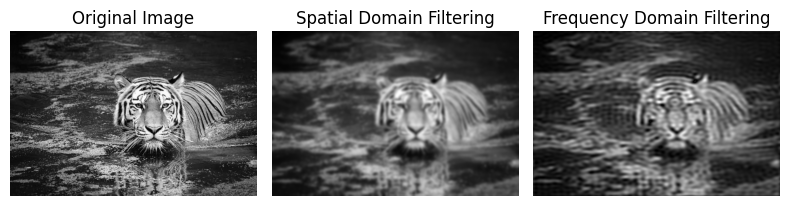

Spatial and frequency domain filtering completed successfully!


In [ ]:
img = cv2.imread("/content/tiger.jpeg", 0)
if img is None:
    raise FileNotFoundError("Image not found!")
spatial_result = cv2.GaussianBlur(
    img,
    (15, 15),
    0
)
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
radius = 40
y, x = np.ogrid[:rows, :cols]
distance = np.sqrt(
    (x - ccol) ** 2 +
    (y - crow) ** 2
)
mask = distance <= radius
filtered_frequency = fshift * mask
frequency_result = np.fft.ifft2(
    np.fft.ifftshift(filtered_frequency)
)
frequency_result = np.abs(frequency_result)
frequency_result = cv2.normalize(
    frequency_result,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)
plt.figure(figsize=(8, 8))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(spatial_result, cmap="gray")
plt.title("Spatial Domain Filtering")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(frequency_result, cmap="gray")
plt.title("Frequency Domain Filtering")
plt.axis("off")
plt.tight_layout()
plt.show()
print("Spatial and frequency domain filtering completed successfully!")
#Priyashi(39)